In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os 
import importlib

if 'oscillator_model' not in os.listdir(): 
    os.chdir('..')

import oscillator_model.oscillator
importlib.reload(oscillator_model.oscillator)
from oscillator_model.oscillator import Oscillator

import oscillator_model.fitting
importlib.reload(oscillator_model.fitting)
from oscillator_model.fitting import *


import oscillator_model.utils
importlib.reload(oscillator_model.utils)
from oscillator_model.utils import *

c:\Users\jleus\UW_Distributed_Modeling_Synch\oscillator_model\fitting.py:2: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.optimize import nnls


In [2]:
f_off_pts_NS = np.array([1e0, 1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
L_dBc_pts_NS = np.array([-111.2, -140.0, -156.7, -161.1, -162.0, -162.2, -163.1])

tau_pts_NS = np.array([1.0, 2.0, 4.0, 8.0, 10.0, 20.0, 40.0, 80.0, 100.0, 200.0, 400.0, 800.0, 1000.0, 2000.0, 4000.0])
sigma_y_NS = np.array([5.10e-13, 4.76e-13, 4.67e-13, 4.80e-13, 4.91e-13, 5.27e-13, 5.52e-13, 5.84e-13, 5.99e-13, 7.27e-13, 9.65e-13, 1.61e-12, 1.94e-12, 3.66e-12, 7.37e-12])


f_off_pts_an7 = np.array([1e1, 1e2, 1e3, 1e4, 1e5])
L_dBc_pts_an7 = np.array([-95.0, -125.0, -152.0, -165.0, -170.0])
tau_pts_An7 = np.array([0.1, 1.0])
sigma_y_An7 = np.array([1e-11, 1e-11])

f_off_pts_Fox = np.array([1e1, 1e2, 1e3, 1e4, 1e5, 1e6])
L_dBc_pts_Fox = np.array([-96.0, -121.0, -134.0, -146.0, -155.0, -156.0])

In [3]:
fosc = 10e6
fc = 1e9
fs = 20.0
T= 100.0 
n_periods = 10
n_captures = 1
start_period = 5

NS_coeffs_lin_PSD = fit_oscillator_coeffs_PSD(f_off_pts_NS, L_dBc_pts_NS)
An7_coeffs_lin_PSD = fit_oscillator_coeffs_PSD(f_off_pts_an7, L_dBc_pts_an7)
Fox_coeffs_lin_PSD = fit_oscillator_coeffs_PSD(f_off_pts_Fox, L_dBc_pts_Fox)

oscNS = Oscillator(
    fosc=fosc, 
    fc=fc, 
    fs=fs, 
    T=T,
    n_periods=n_periods,
    n_captures=n_captures,
    start_period=start_period,
    coeffs_lin=NS_coeffs_lin_PSD
)


oscAn7 = Oscillator(
    fosc=fosc, 
    fc=fc, 
    fs=fs, 
    T=T,
    n_periods=n_periods,
    n_captures=n_captures,
    start_period=start_period,
    coeffs_lin=An7_coeffs_lin_PSD
)


oscFox = Oscillator(
    fosc=fosc, 
    fc=fc, 
    fs=fs, 
    T=T,
    n_periods=n_periods,
    n_captures=n_captures,
    start_period=start_period,
    coeffs_lin=Fox_coeffs_lin_PSD
)

In [4]:
fgrid = np.logspace(-3, 6, 2000)
_, S1_vals_lin_NS = oscNS.S1(fgrid)
S1_vals_dB_NS = S1_to_dBcHz(S1_vals_lin_NS)

_, S1_vals_lin_An7 = oscAn7.S1(fgrid)
S1_vals_dB_An7 = S1_to_dBcHz(S1_vals_lin_An7)

_, S1_vals_lin_Fox = oscFox.S1(fgrid)
S1_vals_dB_Fox = S1_to_dBcHz(S1_vals_lin_Fox)

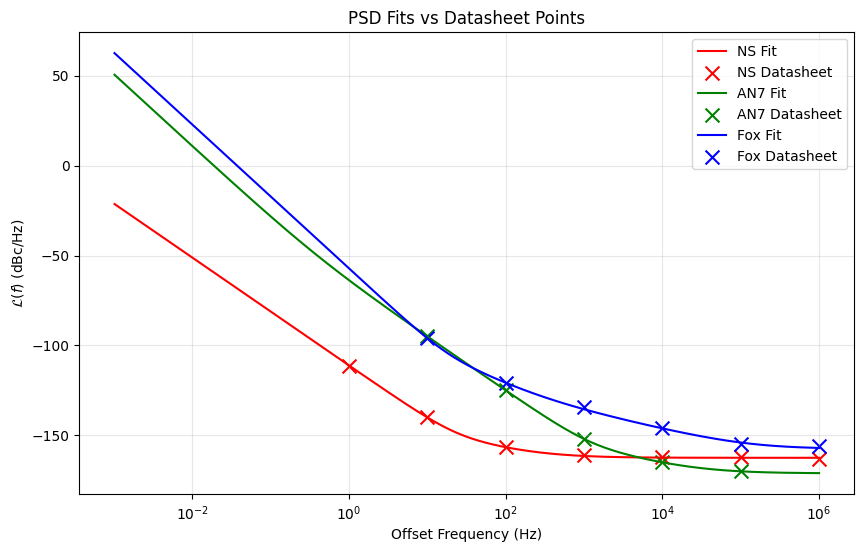

In [5]:
plt.figure(figsize=(10, 6))

plt.semilogx(fgrid[1:], S1_vals_dB_NS[1:], '-', color='red', label='NS Fit')
plt.scatter(f_off_pts_NS, L_dBc_pts_NS, marker='x', color='red', s=100, label='NS Datasheet')

plt.semilogx(fgrid[1:], S1_vals_dB_An7[1:], '-', color='green', label='AN7 Fit')
plt.scatter(f_off_pts_an7, L_dBc_pts_an7, marker='x', color='green', s=100, label='AN7 Datasheet')

plt.semilogx(fgrid[1:], S1_vals_dB_Fox[1:], '-', color='blue', label='Fox Fit')
plt.scatter(f_off_pts_Fox, L_dBc_pts_Fox, marker='x', color='blue', s=100, label='Fox Datasheet')

plt.xlabel('Offset Frequency (Hz)')
plt.ylabel(r'$\mathcal{L}(f)$ (dBc/Hz)')
plt.title('PSD Fits vs Datasheet Points')
plt.legend()
plt.grid(True, which='both', alpha=0.3)


In [6]:
oscNS.realize_phase_error()
oscAn7.realize_phase_error()
oscFox.realize_phase_error()

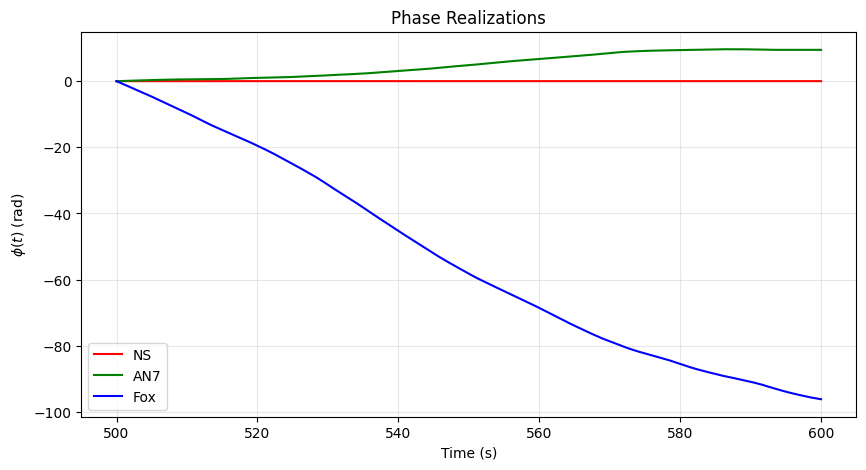

In [7]:
plt.figure(figsize=(10, 5))
plt.plot(oscNS.t_out, oscNS.phi_out - oscNS.phi_out[0], color='red', label='NS')
plt.plot(oscAn7.t_out, oscAn7.phi_out - oscAn7.phi_out[0], color='green', label='AN7')
plt.plot(oscFox.t_out, oscFox.phi_out - oscFox.phi_out[0], color='blue', label='Fox')
plt.xlabel('Time (s)')
plt.ylabel(r'$\phi(t)$ (rad)')
plt.title('Phase Realizations')
plt.legend()
plt.grid(True, alpha=0.3)

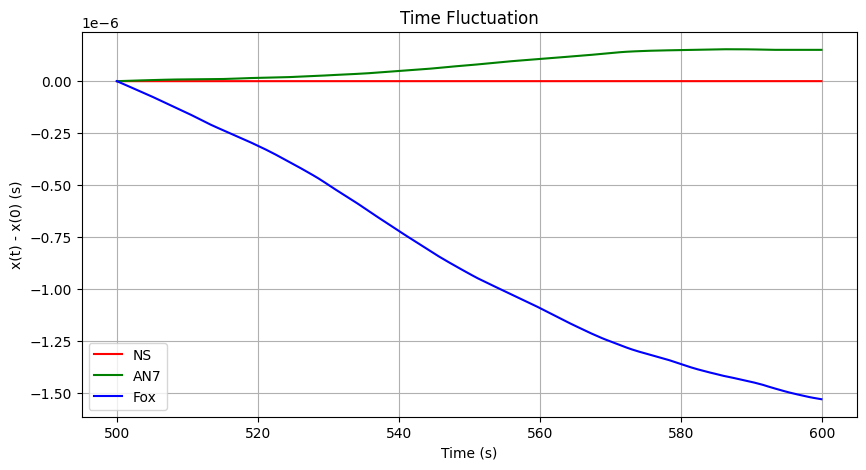

In [8]:
x_NS = oscNS.time_fluctuation(oscNS.phi_out)
x_An7 = oscAn7.time_fluctuation(oscAn7.phi_out)
x_Fox = oscFox.time_fluctuation(oscFox.phi_out)

plt.figure(figsize=(10, 5))
plt.plot(oscNS.t_out, x_NS - x_NS[0], color='red', label='NS')
plt.plot(oscAn7.t_out, x_An7 - x_An7[0], color='green', label='AN7')
plt.plot(oscFox.t_out, x_Fox - x_Fox[0], color='blue', label='Fox')
plt.xlabel('Time (s)')
plt.ylabel('x(t) - x(0) (s)')
plt.title('Time Fluctuation')
plt.legend()
plt.grid()

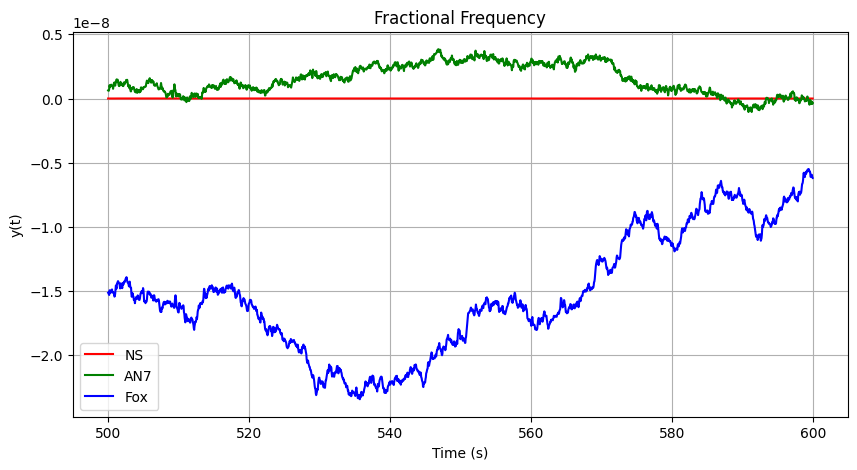

In [9]:
y_NS = oscNS.fractional_frequency(oscNS.phi_out)
y_An7 = oscAn7.fractional_frequency(oscAn7.phi_out)
y_Fox = oscFox.fractional_frequency(oscFox.phi_out)

plt.figure(figsize=(10, 5))
plt.plot(oscNS.t_out[1:], y_NS, color='red', label='NS')
plt.plot(oscAn7.t_out[1:], y_An7, color='green', label='AN7')
plt.plot(oscFox.t_out[1:], y_Fox, color='blue', label='Fox')
plt.xlabel('Time (s)')
plt.ylabel('y(t)')
plt.title('Fractional Frequency')
plt.legend()
plt.grid()